# Multiple Linear Regression and Feature Selection

This notebook covers Multiple Linear Regression, feature selection techniques, and feature engineering.

## Topics Covered:
1. Multiple Linear Regression implementation
2. Feature Selection Techniques
3. Feature Engineering
4. Model Evaluation

In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import r2_score, mean_squared_error

%matplotlib inline


## 1. Generate Synthetic Data with Multiple Features

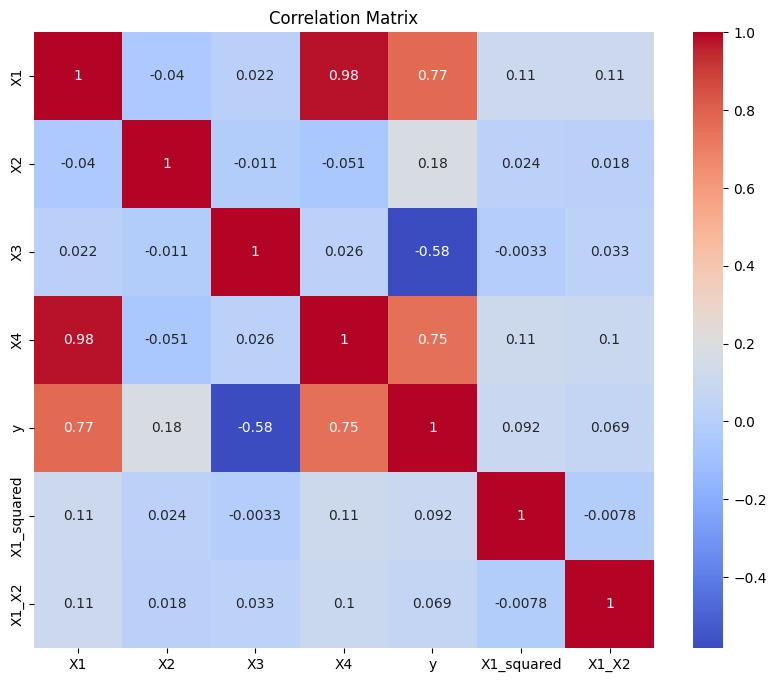

In [21]:
np.random.seed(42)
n_samples = 1000

# Generate features
X1 = np.random.normal(0, 1, n_samples)
X2 = np.random.normal(0, 1, n_samples)
X3 = np.random.normal(0, 1, n_samples)
X4 = 0.5 * X1 + np.random.normal(0, 0.1, n_samples)  # Correlated with X1


# Generate target with noise
y = 2*X1 + 0.5*X2 - 1.5*X3 + np.random.normal(0, 0.1, n_samples)

# Create DataFrame
data = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'X4': X4,
    'y': y
})

# Add polynomial features
data['X1_squared'] = data['X1'] ** 2
data['X1_X2'] = data['X1'] * data['X2']

# Display correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(),annot=True ,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [22]:
data.head()

,X1,X2,X3,X4,y,X1_squared,X1_X2
0,0.496714,1.399355,-0.675178,0.057576,2.619524,0.246725,0.695080
1,-0.138264,0.924634,-0.144519,-0.155171,0.399446,0.019117,-0.127844
2,0.647689,0.059630,-0.792420,0.282484,2.515624,0.419500,0.038622
3,1.523030,-0.646937,-0.307962,0.950284,3.231797,2.319620,-0.985304
4,-0.234153,0.698223,-1.893615,-0.061421,2.584541,0.054828,-0.163491


## 2. Feature Selection Techniques

Feature Importance Scores:
      Feature      F_Score        P_Value
0          X1  1483.113591  1.416359e-199
3          X4  1296.871732  1.184550e-182
2          X3   513.032209   5.553192e-92
1          X2    32.081808   1.932554e-08
4  X1_squared     8.524660   3.582422e-03
5       X1_X2     4.806096   2.858955e-02


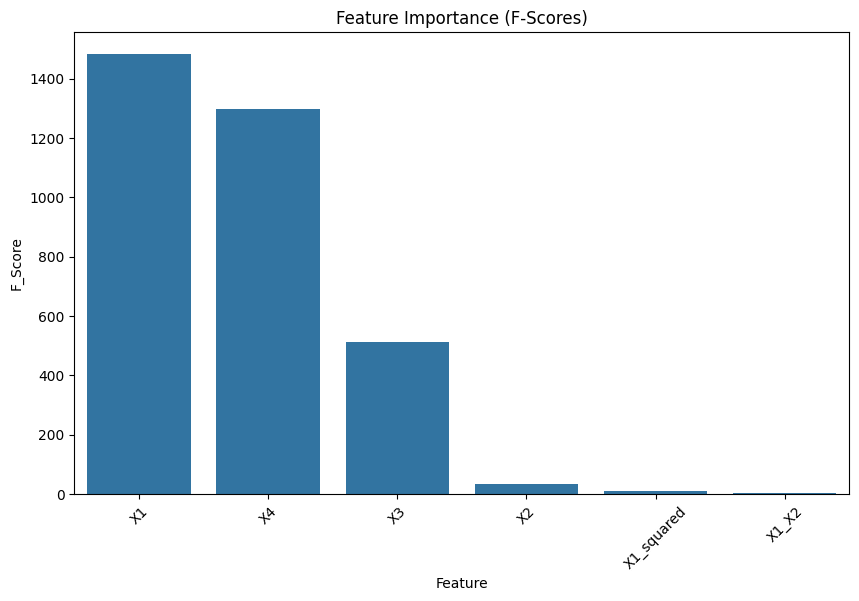

In [26]:
def analyze_feature_importance(X, y, feature_names):
    # Univariate feature selection
    selector = SelectKBest(score_func=f_regression, k=3)
    selector.fit(X, y)
    
    # Get scores and p-values
    scores = pd.DataFrame({
        'Feature': feature_names,
        'F_Score': selector.scores_,
        'P_Value': selector.pvalues_
    })
    
    return scores.sort_values('F_Score', ascending=False)

# Prepare features
X = data.drop('y', axis=1)
feature_names = X.columns

# Analyze feature importance
importance_scores = analyze_feature_importance(X, y, feature_names)
print("Feature Importance Scores:")
print(importance_scores)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='F_Score', data=importance_scores)
plt.title('Feature Importance (F-Scores)')
plt.xticks(rotation=45)
plt.show()

In [32]:
importance_scores['Is_valid'] = importance_scores['P_Value'] < 0.05
importance_scores

,Feature,F_Score,P_Value,Is_valid
0,X1,1483.113591,1.416359e-199,True
3,X4,1296.871732,1.184550e-182,True
2,X3,513.032209,5.553192e-92,True
1,X2,32.081808,1.932554e-08,True
4,X1_squared,8.524660,3.582422e-03,True
5,X1_X2,4.806096,2.858955e-02,True


## 3. Feature Engineering

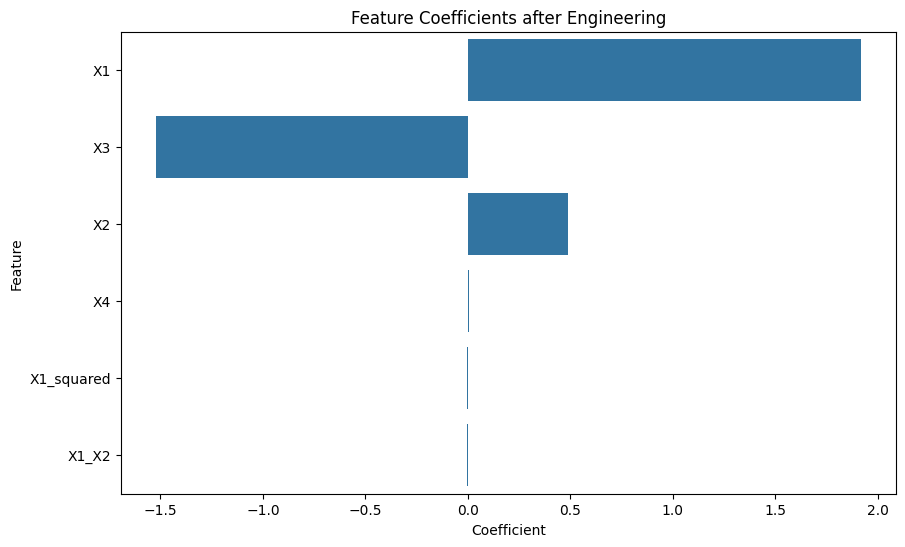

In [20]:
# Add polynomial features
data['X1_squared'] = data['X1'] ** 2
data['X1_X2'] = data['X1'] * data['X2']

# Standardize features
scaler = StandardScaler()
X = data.drop('y', axis=1)
y = data['y']


# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Get feature coefficients
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model.coef_
})
coefficients = coefficients.sort_values('Coefficient', key=abs, ascending=False)

# Plot coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title('Feature Coefficients after Engineering')
plt.show()

## 4. Model Evaluation

Model Performance:
Training R² Score: 0.9983
Test R² Score: 0.9986
Training RMSE: 0.0998
Test RMSE: 0.0958


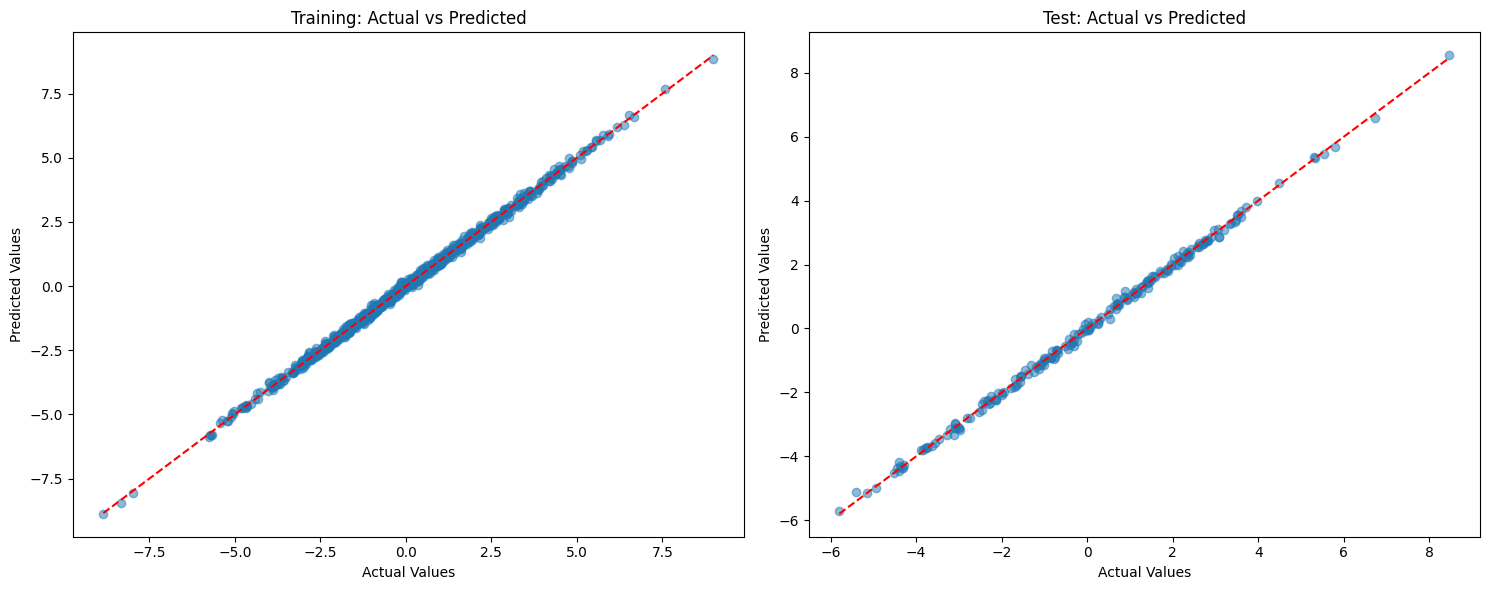

In [6]:
# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Model Performance:")
print(f"Training R² Score: {train_r2:.4f}")
print(f"Test R² Score: {test_r2:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

# Plot actual vs predicted
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.scatter(y_train, y_train_pred, alpha=0.5)
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
ax1.set_xlabel('Actual Values')
ax1.set_ylabel('Predicted Values')
ax1.set_title('Training: Actual vs Predicted')

ax2.scatter(y_test, y_test_pred, alpha=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax2.set_xlabel('Actual Values')
ax2.set_ylabel('Predicted Values')
ax2.set_title('Test: Actual vs Predicted')

plt.tight_layout()
plt.show()